# 📱 Mobile Price Range Classification — K-Nearest Neighbors (KNN)

**🇹🇷 Türkçe:**
Bu notebook, telefonların donanım özelliklerinden (RAM, batarya kapasitesi, ekran çözünürlüğü, dahili hafıza vb.) fiyat aralığını tahmin eden bir K-En Yakın Komşu (KNN) sınıflandırıcısı kuruyor. Hedef değişken `price_range` dört sınıflı: `0` (ucuz) → `3` (çok pahalı).

Notebook'un asıl öğretici noktası şu: **KNN'de ölçekleme her zaman doğru tercih değildir.** `Pipeline` ve `ColumnTransformer` ile kurulmuş sızıntısız bir yapı üzerinde, ölçekli ve ölçeksiz iki modeli `GridSearchCV` ile ayrı ayrı optimize edip karşılaştırıyoruz — ve bu veri setinde ölçeklemenin doğruluğu **%93'ten %61'e** düşürdüğünü gösteriyoruz.

**🇬🇧 English:**
This notebook builds a K-Nearest Neighbors (KNN) classifier that predicts a phone's price bracket from its hardware specs (RAM, battery power, screen resolution, internal memory, and so on). The target `price_range` has four classes: `0` (cheap) → `3` (very expensive).

The central lesson here is that **scaling is not automatically the right choice for KNN.** Using a leakage-free `Pipeline` + `ColumnTransformer` setup, we tune a scaled and an unscaled model separately with `GridSearchCV` and compare them — showing that on this dataset scaling drops accuracy from **93% to 61%**.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Tüm importlar tek hücrede toplandı. Notebook'un ilerleyen bölümlerine dağıtmak yerine baştan tanımlamak, hücreleri sırasız çalıştırdığında ortaya çıkan `NameError` hatalarını önler.

**🇬🇧 English:**
All imports are collected in a single cell. Declaring them up front — rather than scattering them through the notebook — prevents the `NameError` failures that appear when cells are executed out of order.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Mobile Price Classification veri seti yükleniyor. 2000 satır ve 21 kolondan oluşuyor: 20 özellik ve 1 hedef değişken (`price_range`).

**🇬🇧 English:**
The Mobile Price Classification dataset is loaded. It contains 2,000 rows and 21 columns: 20 features and one target variable (`price_range`).

In [2]:
df = pd.read_csv("../../Data/19-mobile_price_knn.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`describe()` ile her kolonun dağılımına, `info()` ile veri tiplerine bakıyoruz. Dikkat edilmesi gereken nokta kolonların **ölçek farkı**: `ram` 256–3998 aralığındayken `blue`, `wifi`, `dual_sim` gibi kolonlar sadece 0 veya 1 değeri alıyor. KNN mesafe tabanlı bir algoritma olduğu için bu fark ilerleyen bölümlerde belirleyici olacak.

**🇬🇧 English:**
`describe()` shows each column's distribution and `info()` shows the data types. The key thing to notice is the **difference in scale**: `ram` spans 256–3998 while columns like `blue`, `wifi`, and `dual_sim` only take the values 0 or 1. Since KNN is a distance-based algorithm, this gap turns out to be decisive later on.

In [3]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

## 🧹 3. Eksik Değer ve Kopya Kontrolü / Missing Values and Duplicates

**🇹🇷 Türkçe:**
Modelleme öncesi iki temel kontrol: eksik değer ve kopya satır. Bu veri seti her ikisinde de temiz — hiç `NaN` ve hiç kopya satır yok. Yine de bunu **varsaymak yerine doğrulamak** gerekir; temiz olduğunu bilmeden ilerlemek, ileride sessizce yanlış sonuç üreten hataların en yaygın kaynağıdır.

**🇬🇧 English:**
Two basic checks before modeling: missing values and duplicate rows. This dataset is clean on both counts — no `NaN` values and no duplicates. Even so, this should be **verified rather than assumed**; moving forward without confirming it is one of the most common sources of errors that silently produce wrong results later.

In [5]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

## 🔗 4. Korelasyon Analizi / Correlation Analysis

**🇹🇷 Türkçe:**
Isı haritası bu notebook'un en önemli bulgusunu ortaya koyuyor: `ram` kolonu hedef değişkenle **0.917** korelasyona sahip. Diğer tüm özellikler 0.21'in altında kalıyor. Yani fiyat aralığını neredeyse tek başına RAM belirliyor.

Bu bulgu ileride ölçekleme kararını doğrudan etkileyecek, o yüzden aklımızda tutuyoruz.

**🇬🇧 English:**
The heatmap reveals the single most important finding in this notebook: `ram` correlates with the target at **0.917**. Every other feature stays below 0.21. In other words, RAM alone very nearly determines the price bracket.

This finding directly drives the scaling decision later on, so it is worth holding on to.

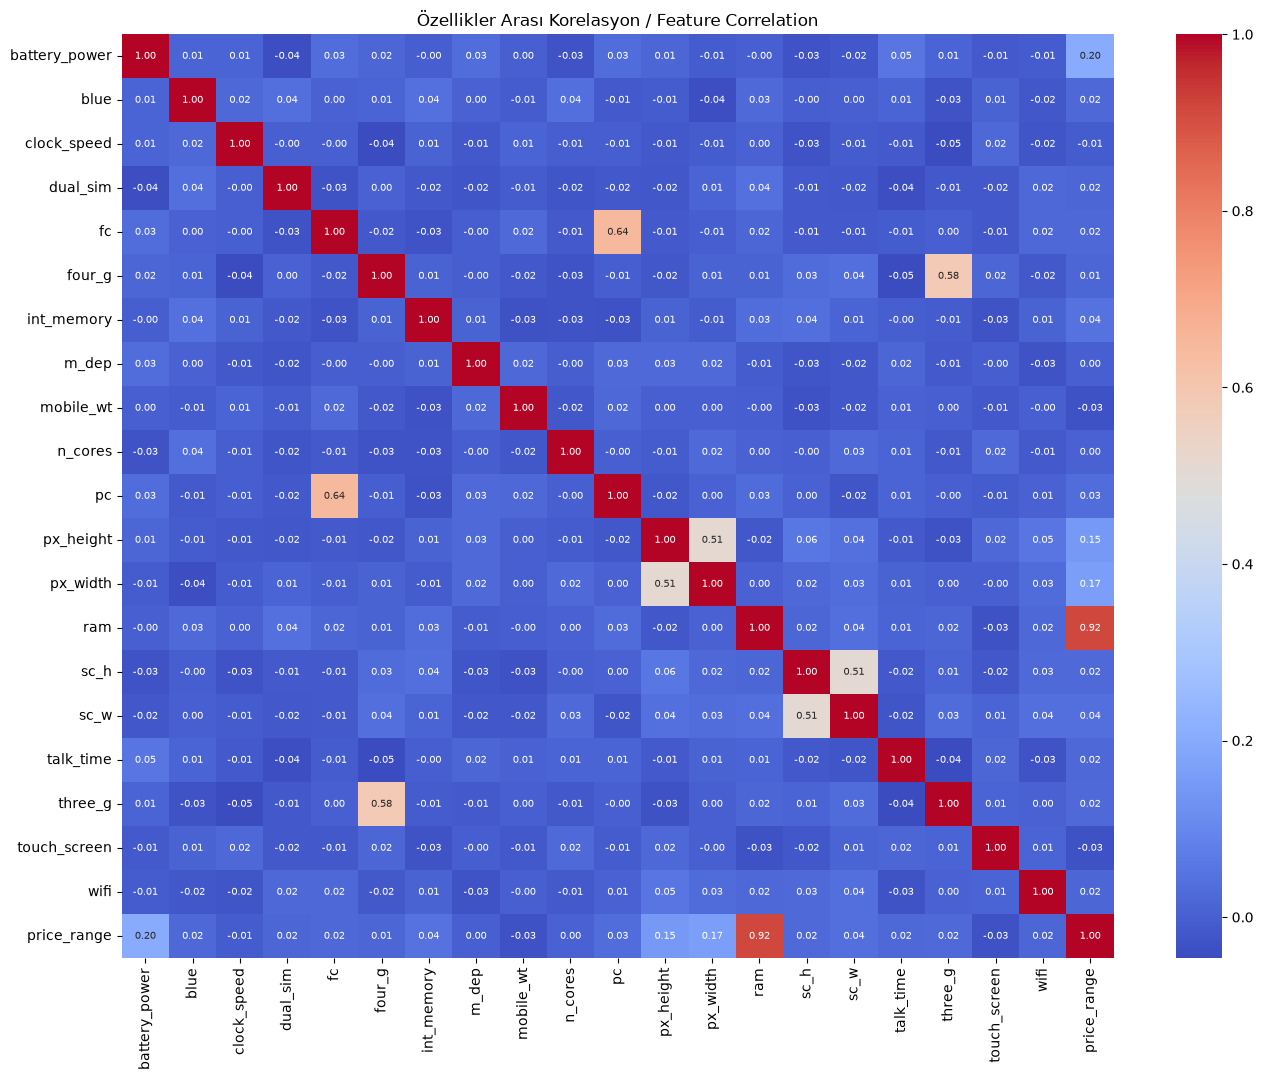

In [7]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 7})
plt.title("Özellikler Arası Korelasyon / Feature Correlation")
plt.show()

In [8]:
# Hedefle korelasyonu en yüksek özellikler / Features most correlated with the target
df.corr()["price_range"].abs().sort_values(ascending=False)[1:8].round(3)

ram              0.917
battery_power    0.201
px_width         0.166
px_height        0.149
int_memory       0.044
sc_w             0.039
pc               0.034
Name: price_range, dtype: float64

## 🎯 5. Hedef Değişkenin Dağılımı / Target Distribution

**🇹🇷 Türkçe:**
`price_range` dört sınıfın her birinde tam 500 örnek içeriyor — mükemmel dengeli bir veri seti. Bu, `accuracy` metriğini güvenle kullanabileceğimiz anlamına geliyor. Dengesiz bir veri setinde doğruluk yanıltıcı olurdu ve `precision`/`recall`'a bakmak zorunda kalırdık.

Rastgele tahmin eden bir modelin doğruluğu %25 olurdu; taban çizgimiz bu.

**🇬🇧 English:**
`price_range` has exactly 500 samples in each of the four classes — a perfectly balanced dataset. This means `accuracy` is a metric we can trust here. On an imbalanced dataset accuracy would be misleading and we would have to lean on `precision`/`recall` instead.

A model guessing at random would score 25%; that is our baseline.

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


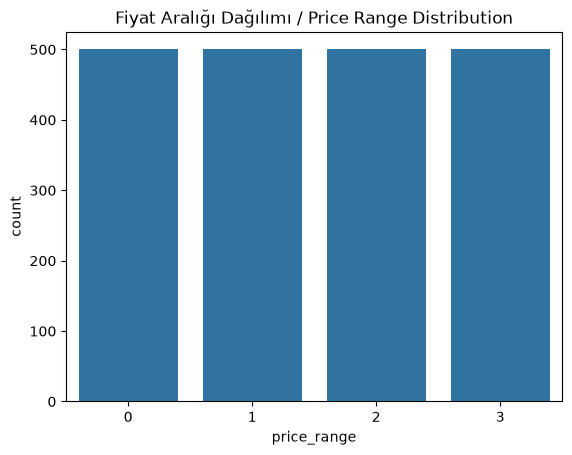

In [9]:
print(df["price_range"].value_counts().sort_index())

sns.countplot(x="price_range", data=df)
plt.title("Fiyat Aralığı Dağılımı / Price Range Distribution")
plt.show()

## ✂️ 6. Özellik/Hedef Ayrımı ve Train-Test Bölme / Feature-Target Split and Train-Test Split

**🇹🇷 Türkçe:**
`X` (özellikler) ve `y` (hedef) ayrıldıktan sonra veri eğitim ve test olarak bölünüyor.

İki noktaya dikkat:
- **Bölme, ön işlemeden önce yapılıyor.** Doldurma ve ölçekleme istatistikleri yalnızca eğitim setinden öğrenilecek; böylece test setinden eğitim setine bilgi sızması (data leakage) engellenir.
- **`stratify=y`** sınıf oranlarını hem eğitim hem test setinde korur. Bu parametre olmadan, mükemmel dengeli bir veri setinde bile bölünme sınıflar arasında %25'e varan sapma gösterebilir.

Ayrıca `ColumnTransformer`'ın kolon **adlarından oluşan bir liste** beklediğine dikkat: buraya bir DataFrame verilirse `ValueError: No valid specification of the columns` hatası alınır.

**🇬🇧 English:**
After separating `X` (features) and `y` (target), the data is split into training and test sets.

Two points to note:
- **The split happens before any preprocessing.** Imputation and scaling statistics will be learned from the training set only, which prevents information from leaking out of the test set into training.
- **`stratify=y`** preserves the class proportions in both splits. Without it, even a perfectly balanced dataset can end up with splits that deviate by as much as 25% between classes.

Also note that `ColumnTransformer` expects a **list of column names**: passing it a DataFrame raises `ValueError: No valid specification of the columns`.

In [10]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

# ColumnTransformer kolon ADLARINDAN oluşan bir liste bekler, DataFrame değil.
# ColumnTransformer expects a list of column NAMES, not a DataFrame.
num_cols = X.columns.tolist()
print(num_cols)

['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=15, stratify=y
)

print("Eğitim / Train:", X_train.shape)
print("Test          :", X_test.shape)
print()
print("Eğitim sınıf dağılımı / Train class balance:")
print(y_train.value_counts().sort_index().to_string())

Eğitim / Train: (1500, 20)
Test          : (500, 20)

Eğitim sınıf dağılımı / Train class balance:
price_range
0    375
1    375
2    375
3    375


## 🔧 7. Ön İşleme Pipeline'ı / Preprocessing Pipeline

**🇹🇷 Türkçe:**
`Pipeline` adımları sırayla çalıştırır: önce `SimpleImputer` eksik değerleri medyanla doldurur, sonra `StandardScaler` kolonları standartlaştırır. `ColumnTransformer` ise bu pipeline'ı hangi kolonlara uygulayacağını belirler.

Sızıntıyı engelleyen mekanizma şudur: `fit()` çağrıldığında istatistikler **yalnızca eğitim verisinden** öğrenilir; `transform()` ise test verisine bu öğrenilmiş değerleri uygular, test kendi istatistiğini asla kullanmaz.

Bu veri setinde eksik değer olmadığı için `SimpleImputer` fiilen bir şey yapmıyor. Yine de bilinçli olarak bırakıldı: pipeline'ı ileride eksik değer içeren yeni verilerle kullanmak istersek hazır olur.

**🇬🇧 English:**
A `Pipeline` runs its steps in order: `SimpleImputer` fills missing values with the median, then `StandardScaler` standardizes the columns. `ColumnTransformer` decides which columns that pipeline is applied to.

The mechanism that prevents leakage is this: when `fit()` is called the statistics are learned **from the training data only**; `transform()` then applies those learned values to the test data, which never uses its own statistics.

Since this dataset has no missing values, `SimpleImputer` is effectively a no-op. It is kept deliberately: it makes the pipeline ready if we later feed it new data that does contain gaps.

In [12]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

prep_scaled = ColumnTransformer([("num", num_pipeline, num_cols)])
model_scaled = Pipeline([("prep", prep_scaled), ("knn", KNeighborsClassifier())])

model_scaled

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

## 🔎 8. Ölçekli Model — Hiperparametre Optimizasyonu / Scaled Model — Hyperparameter Tuning

**🇹🇷 Türkçe:**
`GridSearchCV` ile `k` (komşu sayısı) ve `weights` (ağırlıklandırma) parametrelerini tarıyoruz. Parametre adları `adım_adı__parametre` formatında yazılır — `knn__n_neighbors` ifadesindeki `knn`, pipeline'da o adıma verdiğimiz isimdir.

`cv=5` beş katlı çapraz doğrulama yapar. Tek bir doğrulama setine bakarak `k` seçmek, o sete aşırı uyum riski taşır; çapraz doğrulama bu riski azaltır.

**🇬🇧 English:**
`GridSearchCV` searches over `k` (number of neighbors) and `weights` (weighting scheme). Parameter names follow the `step_name__parameter` format — the `knn` in `knn__n_neighbors` is the name we gave that step in the pipeline.

`cv=5` runs five-fold cross-validation. Choosing `k` from a single validation set risks overfitting to that set; cross-validation reduces that risk.

In [13]:
param_grid = {
    "knn__n_neighbors": range(1, 52, 2),
    "knn__weights": ["uniform", "distance"]
}

grid_scaled = GridSearchCV(model_scaled, param_grid, cv=5, n_jobs=-1)
grid_scaled.fit(X_train, y_train)

print("En iyi parametreler / Best params:", grid_scaled.best_params_)
print("CV skoru / CV score             :", round(grid_scaled.best_score_, 3))
print("Test skoru / Test score         :", round(accuracy_score(y_test, grid_scaled.predict(X_test)), 3))

En iyi parametreler / Best params: {'knn__n_neighbors': 49, 'knn__weights': 'distance'}
CV skoru / CV score             : 0.624


Test skoru / Test score         : 0.608


## ⚖️ 9. Ölçeksiz Model / Unscaled Model

**🇹🇷 Türkçe:**
Şimdi aynı pipeline'ı `StandardScaler` olmadan kuruyoruz — sadece `SimpleImputer` kalıyor. Diğer her şey (aynı bölme, aynı parametre ızgarası, aynı çapraz doğrulama) sabit tutuluyor ki fark yalnızca ölçeklemeden kaynaklansın.

**🇬🇧 English:**
Now we build the same pipeline without `StandardScaler` — only `SimpleImputer` remains. Everything else (same split, same parameter grid, same cross-validation) is held constant so that any difference comes from scaling alone.

In [14]:
prep_unscaled = ColumnTransformer([("num", SimpleImputer(strategy="median"), num_cols)])
model_unscaled = Pipeline([("prep", prep_unscaled), ("knn", KNeighborsClassifier())])

grid_unscaled = GridSearchCV(model_unscaled, param_grid, cv=5, n_jobs=-1)
grid_unscaled.fit(X_train, y_train)

print("En iyi parametreler / Best params:", grid_unscaled.best_params_)
print("CV skoru / CV score             :", round(grid_unscaled.best_score_, 3))
print("Test skoru / Test score         :", round(accuracy_score(y_test, grid_unscaled.predict(X_test)), 3))

En iyi parametreler / Best params: {'knn__n_neighbors': 9, 'knn__weights': 'distance'}
CV skoru / CV score             : 0.933
Test skoru / Test score         : 0.932


## 💡 10. Neden Ölçekleme Burada Zarar Verdi? / Why Did Scaling Hurt Here?

**🇹🇷 Türkçe:**
Sonuç ilk bakışta ders kitabına aykırı görünüyor: KNN mesafe tabanlı olduğu için ölçekleme genellikle **zorunlu** kabul edilir. Burada tam tersi oldu.

Sebep 4. bölümdeki bulguda: `ram` hedefle 0.917 korelasyonlu, diğer 19 özellik ise neredeyse gürültü. `ram` aynı zamanda en geniş aralığa sahip kolon (256–3998).

- **Ölçeksiz:** `ram`'in geniş aralığı Öklid mesafesine doğal olarak hâkim olur. Bu bir kaza değil — mesafe, tam da en bilgilendirici özellik tarafından belirleniyor.
- **Ölçekli:** `StandardScaler` her kolonu ortalama 0, standart sapma 1'e getirir. Artık `ram` ile `wifi` mesafeye **eşit** katkı veriyor. Tek güçlü sinyal, 19 gürültülü özelliğin arasında seyreliyor.

Ölçekli modelin çok yüksek bir komşu sayısında karar kılması da bunun belirtisi: model net bir sinyal bulamadığı için giderek daha geniş komşulukların ortalamasına sığınıyor. Ölçeksiz modele çok daha küçük bir `k` yetiyor.

**Çıkarılacak ders:** "KNN'de her zaman ölçekle" bir başlangıç noktasıdır, bir kanun değil. Özelliklerin ölçekleri anlamlı bir önem sıralaması taşıyorsa, ölçekleme o bilgiyi siler. Doğru yaklaşım kuralı uygulayıp **sonucu veriye doğrulatmaktır**.

**🇬🇧 English:**
At first glance the result contradicts the textbook: because KNN is distance-based, scaling is usually treated as **mandatory**. Here the opposite held.

The reason is the finding from section 4: `ram` correlates with the target at 0.917 while the other 19 features are close to noise. `ram` also happens to have the widest range (256–3998).

- **Unscaled:** the wide range of `ram` naturally dominates the Euclidean distance. This is not an accident — the distance ends up being driven by precisely the most informative feature.
- **Scaled:** `StandardScaler` maps every column to mean 0 and standard deviation 1. Now `ram` and `wifi` contribute **equally** to the distance. The one strong signal gets diluted among 19 noisy features.

The scaled model settling on a very large neighborhood is a symptom of the same thing: unable to find a clear signal, it falls back on averaging ever-wider neighborhoods. The unscaled model needs a far smaller `k`.

**The takeaway:** "always scale for KNN" is a starting point, not a law. When feature scales carry a meaningful ranking of importance, scaling erases that information. The right approach is to apply the rule and then **let the data confirm the result**.

In [15]:
sonuclar = pd.DataFrame({
    "Model": ["Ölçekli / Scaled", "Ölçeksiz / Unscaled"],
    "En iyi k / Best k": [grid_scaled.best_params_["knn__n_neighbors"],
                          grid_unscaled.best_params_["knn__n_neighbors"]],
    "CV skoru / CV score": [round(grid_scaled.best_score_, 3),
                            round(grid_unscaled.best_score_, 3)],
    "Test skoru / Test score": [round(accuracy_score(y_test, grid_scaled.predict(X_test)), 3),
                                round(accuracy_score(y_test, grid_unscaled.predict(X_test)), 3)]
})

sonuclar

,Model,En iyi k / Best k,CV skoru / CV score,Test skoru / Test score
0,Ölçekli / Scaled,49,0.624,0.608
1,Ölçeksiz / Unscaled,9,0.933,0.932


## 📊 11. Nihai Model Değerlendirmesi / Final Model Evaluation

**🇹🇷 Türkçe:**
Ölçeksiz model kazandı, onu detaylı değerlendiriyoruz. `classification_report` sınıf bazında precision, recall ve F1 verir; karışıklık matrisi ise hangi sınıfların birbirine karıştırıldığını gösterir.

Beklenen desen: hatalar ağırlıklı olarak **komşu sınıflar** arasında olur (1 ↔ 2 gibi). Fiyat aralıkları sıralı olduğu için bu mantıklıdır — orta segment iki telefonu ayırmak, en ucuz ile en pahalıyı ayırmaktan zordur.

**🇬🇧 English:**
The unscaled model won, so we evaluate it in detail. `classification_report` gives per-class precision, recall, and F1; the confusion matrix shows which classes get mistaken for one another.

The expected pattern is that errors concentrate between **adjacent classes** (such as 1 ↔ 2). This makes sense because the price brackets are ordered — separating two mid-range phones is harder than separating the cheapest from the most expensive.

In [16]:
best_model = grid_unscaled.best_estimator_
y_pred = best_model.predict(X_test)

print("Doğruluk / Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, digits=3))

Doğruluk / Accuracy: 0.932

              precision    recall  f1-score   support

           0      0.969     0.992     0.980       125
           1      0.908     0.944     0.925       125
           2      0.900     0.864     0.882       125
           3      0.951     0.928     0.939       125

    accuracy                          0.932       500
   macro avg      0.932     0.932     0.932       500
weighted avg      0.932     0.932     0.932       500



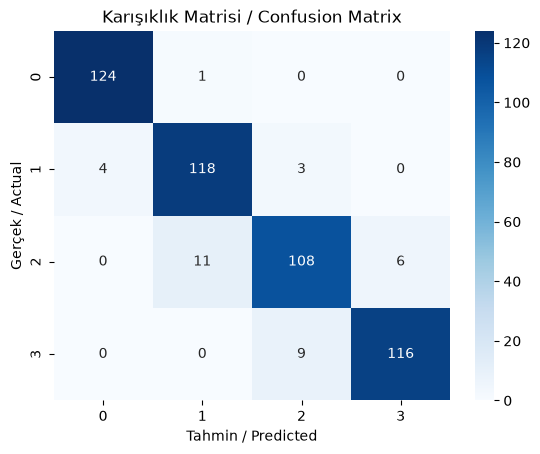

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin / Predicted")
plt.ylabel("Gerçek / Actual")
plt.title("Karışıklık Matrisi / Confusion Matrix")
plt.show()

## 🧭 12. `k` Değerinin Etkisi / The Effect of `k`

**🇹🇷 Türkçe:**
`GridSearchCV`'nin taradığı tüm `k` değerlerinin çapraz doğrulama skorlarını çizerek modelin nasıl davrandığını görüyoruz.

Grafiğin sol ucu (`k=1`) **aşırı öğrenmeyi** temsil eder: model tek bir komşuya baktığı için gürültüyü ezberler. Sağa doğru gidildikçe komşuluk genişler ve model yumuşar; çok sağda ise **yetersiz öğrenme** başlar, model sınıf sınırlarını göremez hale gelir. En iyi `k`, bu iki uç arasındaki dengede bulunur.

**🇬🇧 English:**
Plotting the cross-validation scores across every `k` that `GridSearchCV` tried shows how the model behaves.

The left edge (`k=1`) represents **overfitting**: looking at a single neighbor, the model memorizes noise. Moving right widens the neighborhood and smooths the model; far to the right **underfitting** sets in and the model can no longer see the class boundaries. The best `k` sits at the balance between these two extremes.

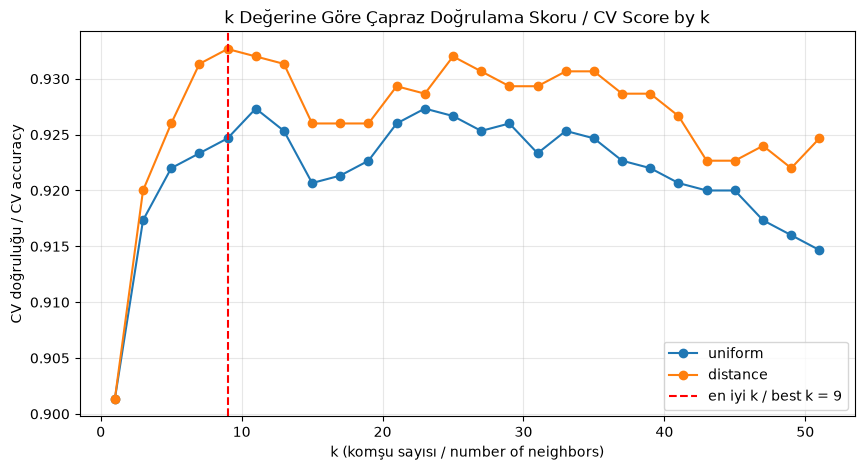

In [18]:
res = pd.DataFrame(grid_unscaled.cv_results_)

plt.figure(figsize=(10, 5))
for w in ["uniform", "distance"]:
    sub = res[res["param_knn__weights"] == w].sort_values("param_knn__n_neighbors")
    plt.plot(sub["param_knn__n_neighbors"], sub["mean_test_score"], marker="o", label=w)

best_k = grid_unscaled.best_params_["knn__n_neighbors"]
plt.axvline(best_k, color="red", linestyle="--", label="en iyi k / best k = %d" % best_k)
plt.xlabel("k (komşu sayısı / number of neighbors)")
plt.ylabel("CV doğruluğu / CV accuracy")
plt.title("k Değerine Göre Çapraz Doğrulama Skoru / CV Score by k")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ✅ 13. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- Ölçeksiz KNN modeli, dört sınıflı fiyat tahmininde **%93.2** test doğruluğuna ulaştı (taban çizgi %25).
- `ram` özelliği tek başına belirleyici: hedefle korelasyonu 0.917.
- **Ölçekleme bu veri setinde doğruluğu 32 puan düşürdü** (%93.2 → %60.8). Sebep, ölçeklemenin en bilgilendirici özelliğin doğal ağırlığını silmesi.
- Tüm ön işleme `Pipeline` + `ColumnTransformer` içinde tanımlandı; istatistikler yalnızca eğitim setinden öğrenildiği için veri sızıntısı yok.
- Hatalar ağırlıklı olarak komşu fiyat sınıfları arasında yoğunlaştı — sıralı bir hedef için beklenen davranış.

**🇬🇧 English:**
- The unscaled KNN model reached **93.2%** test accuracy on the four-class price prediction task (baseline 25%).
- The `ram` feature is decisive on its own: it correlates with the target at 0.917.
- **Scaling cost 32 accuracy points on this dataset** (93.2% → 60.8%), because it erases the natural weight of the most informative feature.
- All preprocessing lives inside a `Pipeline` + `ColumnTransformer`, so statistics are learned from the training set only and there is no data leakage.
- Errors concentrate between adjacent price classes — the expected behavior for an ordered target.